# ERA5 + MeteoChile ML performance

%reload_ext autoreload
%autoreload 2

In [1]:
import tensorflow as tf
import os
import numpy as np
import random
import keras
import xarray as xr
import sys
import matplotlib.pyplot as plt
import pickle
import pandas as pd
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense, Dropout, GRU, Conv1D, Flatten, Reshape
from tensorflow.keras.callbacks import EarlyStopping


In [ ]:
# Add the folder to the Python path

os.chdir("../")
# change working directory to project's root path
print(os.getcwd())

folder_path = os.path.abspath("functions/") #INPUT_PATH)#'path_to_your_folder')  # Replace with the actual folder path
sys.path.insert(0, folder_path)

from Predictions import (
    PredictionModel,
    SERA,
    compute_adjusted_boxplot_bounds,
    XGBCustomObjective,
    sera_objective,
    piecewise_linear_phi_2
)
from indices import get_heatwaves_indices, transform_time_label

c:\Users\marti\Desktop\data\hw_extra


c:\Users\marti\AppData\Local\Programs\Python\Python310\lib\site-packages\tensorflow_addons\utils\tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


In [3]:
SEED = 42

def set_seeds(seed=SEED):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    tf.random.set_seed(seed)
    np.random.seed(seed)
    keras.utils.set_random_seed(seed)

def set_global_determinism(seed=SEED):
    set_seeds(seed=seed)

    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
    
    tf.config.threading.set_inter_op_parallelism_threads(1)
    tf.config.threading.set_intra_op_parallelism_threads(1)

# Call the above function with seed value
set_global_determinism(seed=SEED)

## Load Data

In [4]:
hws_chile = pd.read_csv("data/local_data/monthly/hws_chile_new_agg.csv")

hws_chile["time"] = pd.to_datetime(hws_chile["Unnamed: 0"],format='%Y-%m')
hws_chile.set_index('time', inplace=True)
hws_chile.drop(columns="Unnamed: 0", inplace=True)
indices = list(hws_chile.columns)
# hws_chile = hws_chile[["hwn", "hwf", "hwd", "hwm", "hwa", "hwmeani"]]
hws_chile

,hwn,hwf,hwd,hwm,hwa,hwmeand,hwi,hwmaxi,hwmeani
time,,,,,,,,,
1971-01-01,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
1971-02-01,0.2,0.7,0.7,0.447148,0.807169,0.7,1.508644,1.508644,1.508644
1971-03-01,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
1971-04-01,0.2,0.6,0.6,0.637038,0.982249,0.6,1.911113,1.911113,1.911113
1971-05-01,0.1,0.3,0.3,0.555671,0.901254,0.3,1.667013,1.667013,1.667013
...,...,...,...,...,...,...,...,...,...
2024-08-01,0.4,1.3,1.3,0.759857,1.294393,1.3,2.501609,2.501609,2.501609
2024-09-01,0.2,0.6,0.6,0.367076,0.617588,0.6,1.101228,1.101228,1.101228
2024-10-01,0.4,1.2,0.9,0.853280,1.349775,0.9,3.552305,2.792164,2.559840


In [5]:
with open("data/03_primary/drivers/era5_dict.pickle", 'rb') as handle:
    era5_v2 = pickle.load(handle)
era5_df = pd.concat((era5_v2["ERA5"],hws_chile),axis=1)
era5_df = era5_df[era5_df.index.year > 1970]
era5_df

,nino12,nino34,anom_wind_cl_raco,anom_wind_cl_puelche,anom_wind_pressure,anom_ta_cl,anom_pdo,anom_psl_sam_40,anom_psl_sam_65,anom_dmi_east,...,adv_chile,hwn,hwf,hwd,hwm,hwa,hwmeand,hwi,hwmaxi,hwmeani
time,,,,,,,,,,,,,,,,,,,,,
1971-01-01,-1.323449,-1.479654,0.004568,1.626114,-155.360306,-2.929806,-0.074776,-112.387703,341.377930,-0.536907,...,4.134146,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
1971-02-01,-1.141428,-1.604307,-0.288501,0.221068,-98.484497,-0.503788,-0.037966,57.690361,51.769032,-0.933078,...,0.214954,0.2,0.7,0.7,0.447148,0.807169,0.7,1.508644,1.508644,1.508644
1971-03-01,-1.170822,-1.821136,-0.237063,0.329253,-77.386848,-1.261046,-0.144552,6.743707,-146.034164,-0.957672,...,0.069712,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
1971-04-01,-0.556328,-1.182318,-0.485039,-0.753484,198.601791,-1.349036,-0.087349,-70.511070,233.869843,-0.813266,...,-1.091872,0.2,0.6,0.6,0.637038,0.982249,0.6,1.911113,1.911113,1.911113
1971-05-01,-1.159086,-1.029230,-0.084317,0.738629,185.134171,0.668153,-0.267097,-178.369583,701.905396,-0.772716,...,-0.240826,0.1,0.3,0.3,0.555671,0.901254,0.3,1.667013,1.667013,1.667013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-01,-0.107980,0.082571,-0.306670,-1.884179,452.930206,-1.053086,1.098336,-203.018234,536.929138,0.361525,...,-1.233973,0.4,1.3,1.3,0.759857,1.294393,1.3,2.501609,2.501609,2.501609
2024-09-01,-0.487674,-0.298912,0.694752,3.229236,-654.225525,-0.559750,1.172889,281.185516,-122.286896,0.537031,...,2.535206,0.2,0.6,0.6,0.367076,0.617588,0.6,1.101228,1.101228,1.101228
2024-10-01,-0.374066,-0.440446,-0.493092,-1.423323,114.399475,2.943502,1.171113,-6.615347,21.412451,0.930432,...,4.639970,0.4,1.2,0.9,0.853280,1.349775,0.9,3.552305,2.792164,2.559840


## SERA Bounds Example

In [6]:
def average_bounds(list_bounds):
    result_bounds = []
    result_bounds.append(np.min([b[0] for b in list_bounds]))
    result_bounds.append(np.mean([b[1] for b in list_bounds]))
    result_bounds.append(np.mean([b[2] for b in list_bounds]))
    result_bounds.append(np.max([b[3] for b in list_bounds]))
    print("Result bounds", result_bounds)
    return result_bounds

In [7]:
hws_training = hws_chile[hws_chile.index.year <2018]
scaler = StandardScaler()
hws_scaled_training = hws_training.copy(deep=True)
hws_scaled_training[indices] = scaler.fit_transform(hws_scaled_training[indices])
pd.options.display.float_format = "{:,.2f}".format
hws_scaled_training.describe()

,hwn,hwf,hwd,hwm,hwa,hwmeand,hwi,hwmaxi,hwmeani
count,564.00,564.00,564.00,564.00,564.00,564.00,564.00,564.00,564.00
mean,-0.00,-0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.87,-0.77,-0.88,-0.83,-0.81,-0.91,-0.64,-0.71,-0.75
25%,-0.87,-0.77,-0.88,-0.83,-0.81,-0.91,-0.64,-0.71,-0.75
50%,-0.30,-0.37,-0.32,-0.40,-0.39,-0.31,-0.40,-0.40,-0.41
75%,0.56,0.31,0.52,0.45,0.45,0.59,0.18,0.28,0.36
max,5.39,6.94,5.57,4.30,4.61,4.39,7.79,7.43,5.26


In [8]:
bounds_paper_list = []
for i, index in enumerate(indices):
    hws_index = hws_scaled_training[[index]].to_numpy()
    hws_index = hws_index.reshape(hws_index.shape[0])
    l, m ,u  = compute_adjusted_boxplot_bounds(hws_index)
    bounds_paper = (l, m, u, max(hws_index))
    bounds_paper_list.append(bounds_paper)

bounds_avg = average_bounds(bounds_paper_list)

Result bounds [-1.5011122833746553, -0.36584072934073864, 7.120116294833575, 7.7937161476092776]


## Training, val, test on 5 Models

- Split train, validation and test datasets: 1971-2018, 2019-2022, 2023-2024
- Normalize features and labels on training (save scalers for afterwards)
- Compute SERA Bounds based on training distributions (same fn for all labels)
- Compile keras model
- Train
- Predict
- Performance on full span train and predict (no problem sera, is always same bounds -> same fn)
- Performance on test

In [ ]:
## Data
features = list(era5_v2["ERA5"].columns)
labels = indices

X = era5_df[features]
y = era5_df[labels]

## Split
len_val = 5*12
len_test = 2*12

X_train, X_test, y_train, y_test = X[:-len_test], X[-len_test:], y[:-len_test], y[-len_test:]
X_train, X_val, y_train, y_val = X_train[:-len_val], X_train[-len_val:], y_train[:-len_val], y_train[-len_val:]

## Scaling
features_scaler = StandardScaler()
labels_scaler = StandardScaler()
X_train_scaled = features_scaler.fit_transform(X_train)
y_train_scaled = labels_scaler.fit_transform(y_train)
X_val_scaled = features_scaler.transform(X_val)
y_val_scaled = labels_scaler.transform(y_val)
X_test_scaled = features_scaler.transform(X_test)
y_test_scaled = labels_scaler.transform(y_test)


## SERA
bounds_paper_list = []
for i, label in enumerate(labels):
    y_train_label = y_train_scaled[:, i]
    # y_train_label = y_train_label.reshape(y_train_label.shape[0])
    l, m ,u  = compute_adjusted_boxplot_bounds(y_train_label)
    bounds_paper = (l, m, u, max(y_train_label))
    bounds_paper_list.append(bounds_paper)

bounds_avg = average_bounds(bounds_paper_list)
# bounds_avg = [-1.5366946087281974, -0.4163184421933129, 6.860691104388604, 7.339525422290547]
sera_loss = SERA(bounds=bounds_avg,T=100, initial_weight=0.1, fn="piecewise2")


## Models
rnn16_model = Sequential([
    SimpleRNN(16, activation="tanh", input_shape=(1, len(features))),
    Dropout(0.1),
    Dense(8, activation="relu"),
    Dense(len(labels)) 
])
lstm16_model = Sequential([
    LSTM(16, activation="tanh", input_shape=(1, len(features))),
    Dropout(0.1),  # Regularization
    Dense(8, activation="relu"),
    Dense(len(labels))  # Predict 5 indices
])
cnn_rnn_model = Sequential([
    Conv1D(16, kernel_size=1, activation="relu", input_shape=(1, len(features))),
    Reshape((1, 16)),  # Back to time dimension
    SimpleRNN(8, activation="tanh"),
    Dropout(0.1),
    Dense(len(labels))
])
lp_model = Sequential([
    Flatten(input_shape=(1, len(features))),
    Dense(16, activation="relu"),
    Dropout(0.1),
    Dense(8, activation="relu"),
    Dense(len(labels))
])
xgb_model = XGBCustomObjective(
        objective_func=sera_objective(piecewise_linear_phi_2(bounds_avg, initial_weight=0.1)),
        n_estimators=15,
        learning_rate=0.1
    )
models = {
    # "RNN16" : rnn16_model,
    # "LSTM16" : lstm16_model,
    # "CNNRNN16": cnn_rnn_model,
    # "MLP16": lp_model,
    "XGB15" : xgb_model
}
models_results = {model: {} for model in models.keys()}

for name, model in models.items():
    # Prediction dfs
    df_pred_train = pd.DataFrame(columns=labels, index=X_train.index)
    df_pred_val= pd.DataFrame(columns=labels, index=X_val.index)
    df_pred_test = pd.DataFrame(columns=labels, index=X_test.index)
    df_pred_train_unscaled = pd.DataFrame(columns=labels, index=X_train.index)
    df_pred_val_unscaled= pd.DataFrame(columns=labels, index=X_val.index)
    df_pred_test_unscaled = pd.DataFrame(columns=labels, index=X_test.index)

    for i in range(1,13):
        ## Data by season
        X_train_season, y_train_season = X_train[X_train.index.month==i], y_train[y_train.index.month==i] 
        X_val_season, y_val_season = X_val[X_val.index.month==i], y_val[y_val.index.month==i] 
        X_test_season, y_test_season = X_test[X_test.index.month==i], y_test[y_test.index.month==i] 

        ## Scale
        X_train_season_scaled = features_scaler.transform(X_train_season)
        y_train_season_scaled = labels_scaler.transform(y_train_season)
        X_val_season_scaled = features_scaler.transform(X_val_season)
        y_val_season_scaled = labels_scaler.transform(y_val_season)
        X_test_season_scaled = features_scaler.transform(X_test_season)
        y_test_season_scaled = labels_scaler.transform(y_test_season)

        ## Reshape for keras
        X_train_season_keras = np.expand_dims(X_train_season_scaled, axis=1)
        X_val_season_keras = np.expand_dims(X_val_season_scaled, axis=1)
        X_test_season_keras = np.expand_dims(X_test_season_scaled, axis=1)

        # Clone model to reset weights for new season
        if i != 1:
            model = tf.keras.models.clone_model(model)

        # Compile
        model.compile(optimizer="adam", loss=sera_loss)

        # Training
        early_stopping = EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)
        model.fit(X_train_season_keras, y_train_season_scaled, epochs=200, batch_size=8, verbose=0, callbacks=[early_stopping], validation_data=(X_val_season_keras, y_val_season_scaled))
       
        # Prediction
        y_pred_train_season = model.predict(X_train_season_keras)
        y_pred_val_season = model.predict(X_val_season_keras)
        y_pred_test_season = model.predict(X_test_season_keras)

        # Arrange in full span
        df_pred_train.loc[X_train_season.index] = y_pred_train_season
        df_pred_train.sort_index(inplace=True)
        df_pred_val.loc[X_val_season.index] = y_pred_val_season
        df_pred_val.sort_index(inplace=True)
        df_pred_test.loc[X_test_season.index] = y_pred_test_season
        df_pred_test.sort_index(inplace=True)
        df_pred_train_unscaled.loc[X_train_season.index] = labels_scaler.inverse_transform(y_pred_train_season)
        df_pred_train_unscaled.sort_index(inplace=True)
        df_pred_val_unscaled.loc[X_val_season.index] = labels_scaler.inverse_transform(y_pred_val_season)
        df_pred_val_unscaled.sort_index(inplace=True)
        df_pred_test_unscaled.loc[X_test_season.index] = labels_scaler.inverse_transform(y_pred_test_season)
        

    df_pred_train = df_pred_train.dropna()
    df_pred_train = df_pred_train.astype(np.number)

    df_pred_val = df_pred_val.dropna()
    df_pred_val = df_pred_val.astype(np.number)

    df_pred_test = df_pred_test.dropna()
    df_pred_test = df_pred_test.astype(np.number)

    df_pred_train_unscaled = df_pred_train_unscaled.dropna()
    df_pred_train_unscaled = df_pred_train_unscaled.astype(np.number)

    df_pred_val_unscaled = df_pred_val_unscaled.dropna()
    df_pred_val_unscaled = df_pred_val_unscaled.astype(np.number)

    df_pred_test_unscaled = df_pred_test_unscaled.dropna()
    df_pred_test_unscaled = df_pred_test_unscaled.astype(np.number)

    # Performance
    models_results[name] = {
        "SERA_training" : np.array([sera_loss.call(y_train_scaled[:, i], df_pred_train[label]) for i,label in enumerate(labels)]),
        "SERA_val" : np.array([sera_loss.call(y_val_scaled[:, i], df_pred_val[label]) for i,label in enumerate(labels)]),
        "SERA_test" : np.array([sera_loss.call(y_test_scaled[:, i], df_pred_test[label]) for i,label in enumerate(labels)]),
        "mae_training": mean_absolute_error(y_train, df_pred_train_unscaled, multioutput="raw_values"),
        "mae_val": mean_absolute_error(y_val, df_pred_val_unscaled, multioutput="raw_values"),
        "mae_test": mean_absolute_error(y_test, df_pred_test_unscaled, multioutput="raw_values"),
    }

Result bounds [-1.5011122833746553, -0.36584072934073864, 7.120116294833575, 7.7937161476092776]
1/1 [==============================] - 0s 22ms/step


c:\Users\marti\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\dtypes\common.py:1687: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  npdtype = np.dtype(dtype)
c:\Users\marti\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\dtypes\common.py:1687: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  npdtype = np.dtype(dtype)
c:\Users\marti\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\dtypes\common.py:1687: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  npdtype = np.dtype(dtype)
c:\Users\marti\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\dtypes\common.py:1687: DeprecationWarning: Converting `np

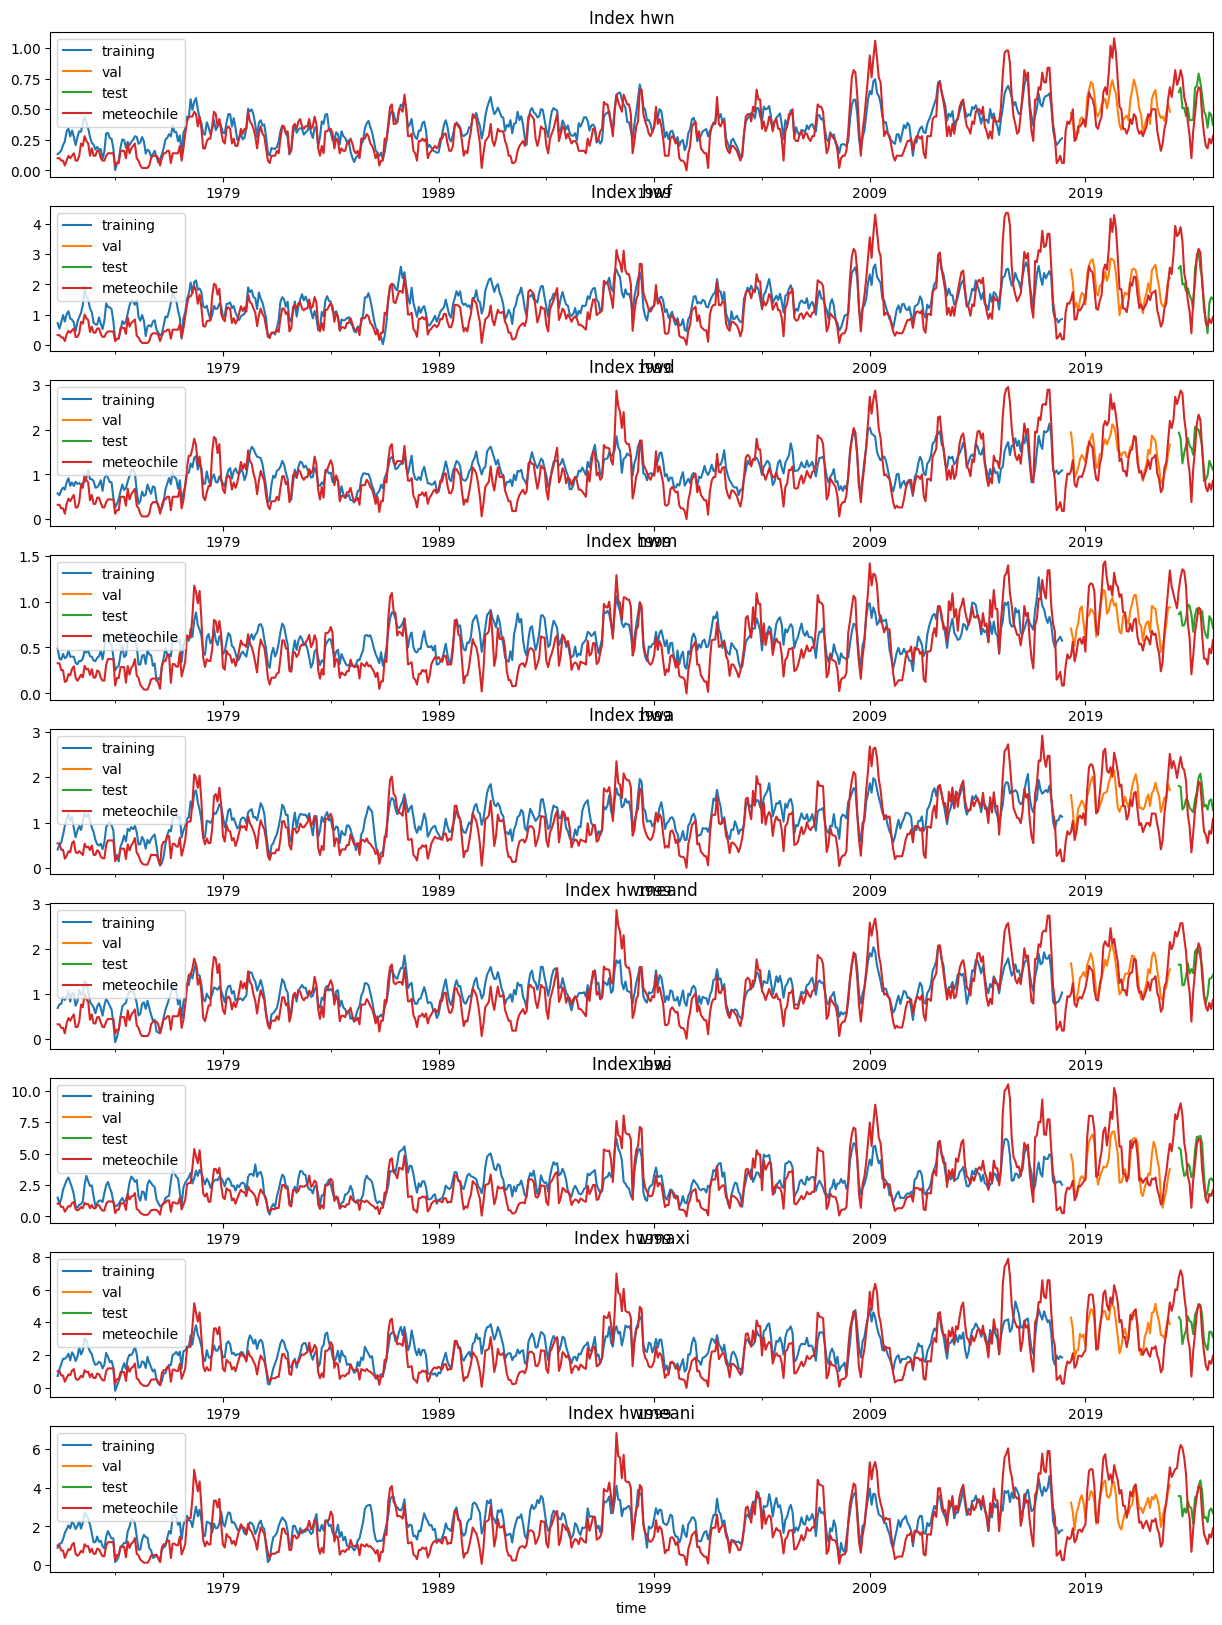

In [52]:
# df_pred_train_yearly = transform_time_label(df_pred_train_unscaled, "year")
# df_pred_val_yearly = transform_time_label(df_pred_val_unscaled, "year")
# df_pred_test_yearly = transform_time_label(df_pred_test_unscaled, "year")
# meteochile_yearly = transform_time_label(hws_chile, "year")
fig, axs = plt.subplots(len(labels), figsize=(15, 20))
for i, index in enumerate(labels):
    df_pred_train_unscaled.rolling(5).mean().plot(y=index, ax=axs[i], label="training")
    df_pred_val_unscaled.rolling(5).mean().plot(y=index, ax=axs[i], label="val")
    df_pred_test_unscaled.rolling(5).mean().plot(y=index, ax=axs[i], label="test")
    hws_chile.rolling(5).mean().plot(y=index, ax=axs[i], label="meteochile")
    axs[i].set_title(f"Index {index}")

In [53]:
models_results["CNNRNN16"]

{'SERA_training': array(<generator object <genexpr> at 0x000002157B9A94D0>, dtype=object),
 'SERA_val': array(<generator object <genexpr> at 0x00000215456AD7E0>, dtype=object),
 'SERA_test': array(<generator object <genexpr> at 0x00000215456AC200>, dtype=object),
 'mae_training': array([0.16397135, 0.7335468 , 0.55822444, 0.30801768, 0.56980324,
        0.49227446, 1.78586212, 1.33337106, 1.22230333]),
 'mae_val': array([0.24028828, 1.01831106, 0.61870327, 0.36872581, 0.79322275,
        0.65004662, 2.4095419 , 1.98748847, 1.72211487]),
 'mae_test': array([0.26885458, 1.40775386, 1.11509687, 0.55137271, 0.9022679 ,
        1.05704306, 2.9088017 , 2.83791648, 2.53946508])}

## 10-fold CV random

10 iterations of:
- Split train, val (90-10), based on years
- Normalize features and labels on training fold (save scalers for afterwards)
- Compute SERA Bounds based on training years (same fn for all labels)
- Compile keras model
- Train
- Predict on val years
- get performances \
Then average performance on vals


In [10]:
from sklearn.model_selection import KFold
kf = KFold(n_splits=10, shuffle=True, random_state=42)

for train_index, test_index in kf.split(era5_df[era5_df.index.month==1]):
    print(train_index)

[ 0  1  2  3  4  6  7  8  9 10 11 13 14 15 16 17 18 20 21 22 23 24 25 26
 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 45 46 47 50 51 52 53]
[ 0  1  2  4  5  6  7  9 10 11 12 14 15 16 18 19 20 21 22 23 24 25 26 27
 28 29 30 31 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 53]
[ 0  1  2  3  5  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 25 27
 28 29 30 31 32 33 35 36 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53]
[ 0  1  2  3  4  5  6  7  8 10 11 12 13 14 17 18 19 20 21 22 23 24 25 26
 27 28 29 30 31 32 34 35 36 37 38 39 40 41 42 43 44 46 47 48 49 51 52 53]
[ 1  2  3  4  5  6  7  8  9 10 12 13 14 15 16 17 18 19 20 21 22 23 24 26
 27 28 29 31 32 33 34 35 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52
 53]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 28 30 32 33 34 35 36 37 38 39 41 42 43 44 45 46 48 49 50 51 52
 53]
[ 0  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 22 23 24 25 26
 27 28 29 30 31 32 33 34 35 36 37 38 

## 5-fold TSCV

5 iterations of:
- Split train, val (5 years of val), based on years
- Normalize features and labels on training fold (save scalers for afterwards)
- Compute SERA Bounds based on training years (same fn for all labels)
- Compile keras model
- Train
- Predict on val years
- get performances \
Then average performance on vals